# 머신러닝 실습 : 고객 구매 데이터로 성별 예측 모델링 (분류 문제)

- 주어진 데이터는 백화점 고객의 1년 간 구매 데이터입니다.
- 고객 3,500명에 대한 학습용 데이터(y.csv, X.csv)를 이용하여 성별예측 모형을 만들어보세요.
- 모델의 성능은 자유롭게 측정해봅니다!

[실습 프로세스]
1. 데이터 불러오기
2. 데이터 탐색
3. 데이터 전처리
4. 학습/테스트 데이터 분할
* 데이터 스케일링
5. 모델 선택 및 학습
6. 예측 및 평가

# 0. 라이브러리 불러오기

- 라이브러리를 가져와서 과정을 준비합니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

# 1. 데이터 불러오기

- 데이터를 가져와서 과정을 준비합시다.
- 인코딩 방식은 'euc-kr' 을 활용하세요.
- 데이터 출처 : 한국데이터산업진흥원 빅데이터분석기사 실기 공개 예시 문항
- 독립 변수 데이터셋 : ./data/X.csv
- 종속 변수 데이터셋 : ./data/y.csv

데이터 파일을 불러옵니다. 보통 CSV 파일을 pandas로 읽어옵니다.

In [2]:
import os
# 노트북 파일이 있는 폴더로 이동 (예시)
os.chdir(r'C:\Users\Admin\hipython\ml')

# 변경 후 확인
# print("변경 후:", os.getcwd())

In [3]:
X = pd.read_csv('./data/X.csv', encoding='euc-kr')
y = pd.read_csv('./data/y.csv', encoding='euc-kr')

In [4]:
X.head()

,cust_id,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,0,68282840,11264000,6860000.0,기타,강남점,19,3.894737,0.527027,17
1,1,2136000,2136000,300000.0,스포츠,잠실점,2,1.500000,0.000000,1
2,2,3197000,1639000,NaN,남성 캐주얼,관악점,2,2.000000,0.000000,1
3,3,16077620,4935000,NaN,기타,광주점,18,2.444444,0.318182,16
4,4,29050000,24000000,NaN,보석,본 점,2,1.500000,0.000000,85


In [5]:
y.head()

,cust_id,gender
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0


>> X.head(), y.head()로 출력된 테이블을 복사해서 GPT에게 요청 

<프롬프트>
 X.head()와 y.head()로 출력된 테이블이야.
첨부한 데이터를 이용해서 고객 성별분류모델을 만들려고 해.

[실습 프로세스]
1. 데이터 불러오기
2. 데이터 탐색
3. 데이터 전처리
4. 학습/테스트 데이터 분리
* 데이터 스케일링
5. 모델 선택 및 학습
6. 예측 및 평가

위의 프로세스에 따라 한 단계씩 진행하려고 해.
LigisticRegression 기준으로 예측 성능을 확인하고,
평가지표는 정확도, 정밀도, 재현율, F1, Confusion_Matrix를 사용하고,
이후 DecisionTree, RandomForest, XGBoost로 모델 성능을 비교할게.

주의사항:
코드 작성 시, 지나치게 복잡하지 않고 최대한 심플한 코드(예를 들어 람다나 3항연산은 배제)를 선호해.
구조 변경이나, 복잡한 제어문, 함수 정의, ml 모델의 함수 호출 등에는 주석을 추가해줘.
각 단계마다 실행결과를 분석해서 노트북셀로 정리하려고 해.
- 주석은 이해하기 쉬운 표현을 사용할 것
- 결과 분석 문장은 마크다운 형식으로 작성할 것(h2, h3는 사용금지)
- 모델링 코드는 ipynb 형식임


# 2. 데이터 탐색하기

- 데이터를 이해할 수 있도록 탐색과정을 수행해봅시다.
- 데이터의 상위 몇 개 행을 출력하여 전체 구조를 미리 확인합니다.
- 데이터의 요약 정보나 통계 정보를 출력해 변수들의 유형과 분포를 확인합니다.

1. 전체 데이터프레임 확인: 행/열수, 데이터 타입 (info)
2. str(범주형) 변수 > 분포 확인 (unique, 히스토그램 시각화)
3. 기초통계량 (describe)
4. 결측치 확인
5. 왜도
6. 상관계수 분석
7. 이상치 탐색

In [6]:
# 전체 데이터 프레임 확인
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cust_id  3500 non-null   int64  
 1   총구매액     3500 non-null   int64  
 2   최대구매액    3500 non-null   int64  
 3   환불금액     1205 non-null   float64
 4   주구매상품    3500 non-null   str    
 5   주구매지점    3500 non-null   str    
 6   내점일수     3500 non-null   int64  
 7   내점당구매건수  3500 non-null   float64
 8   주말방문비율   3500 non-null   float64
 9   구매주기     3500 non-null   int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 273.6 KB


In [7]:
# cust_id 중복개수
dup_x = X['cust_id'].duplicated().sum()
dup_y = y['cust_id'].duplicated().sum()

print('X(cust_id) 중복 개수:', dup_x)
print('y(cust_id) 중복 개수:', dup_y)

X(cust_id) 중복 개수: 0
y(cust_id) 중복 개수: 0


In [8]:
y['gender'].value_counts()  #0 여성, 1 남성

gender
0    2184
1    1316
Name: count, dtype: int64

In [9]:
y["gender"].value_counts(normalize=True, dropna=False).sort_index() * 100

gender
0    62.4
1    37.6
Name: proportion, dtype: float64

해석

- 클래스가 완전히 균형적이진 않지만, 극단적 불균형은 아닌 편입니다.
- 학습/테스트 분리 시에는 분포가 유지되도록 stratify 적용이 중요합니다.
- 단순 다수 클래스 예측만 해도 기대 정확도는 약 62.4% 수준이므로, 모델 성능은 이 기준을 넘는지 함께 보겠습니다.

In [10]:
# 범주형 변수 분포 확인
X['주구매상품'].unique()

<StringArray>
[    '기타',    '스포츠', '남성 캐주얼',     '보석',   '디자이너',   '시티웨어',     '명품',
    '농산물',    '화장품',     '골프',     '구두',   '가공식품',    '수산품',     '아동',
   '차/커피',    '캐주얼',   '섬유잡화',     '육류',   '축산가공',  '젓갈/반찬',   '액세서리',
   '피혁잡화',   '일용잡화',   '주방가전',   '주방용품',   '건강식품',     '가구',     '주류',
  '모피/피혁', '남성 트랜디',     '셔츠',   '남성정장',   '생활잡화',  '트래디셔널', '란제리/내의',
    '커리어',  '침구/수예',   '대형가전', '통신/컴퓨터',     '식기',   '소형가전',     '악기']
Length: 42, dtype: str

In [11]:
X['주구매지점'].unique()

<StringArray>
[  '강남점',   '잠실점',   '관악점',   '광주점',  '본  점',   '일산점',   '대전점',  '부산본점',
   '분당점',  '영등포점',   '미아점',  '청량리점',   '안양점',   '부평점',   '동래점',   '포항점',
   '노원점',   '창원점', '센텀시티점',   '인천점',   '대구점',   '전주점',   '울산점',   '상인점']
Length: 24, dtype: str

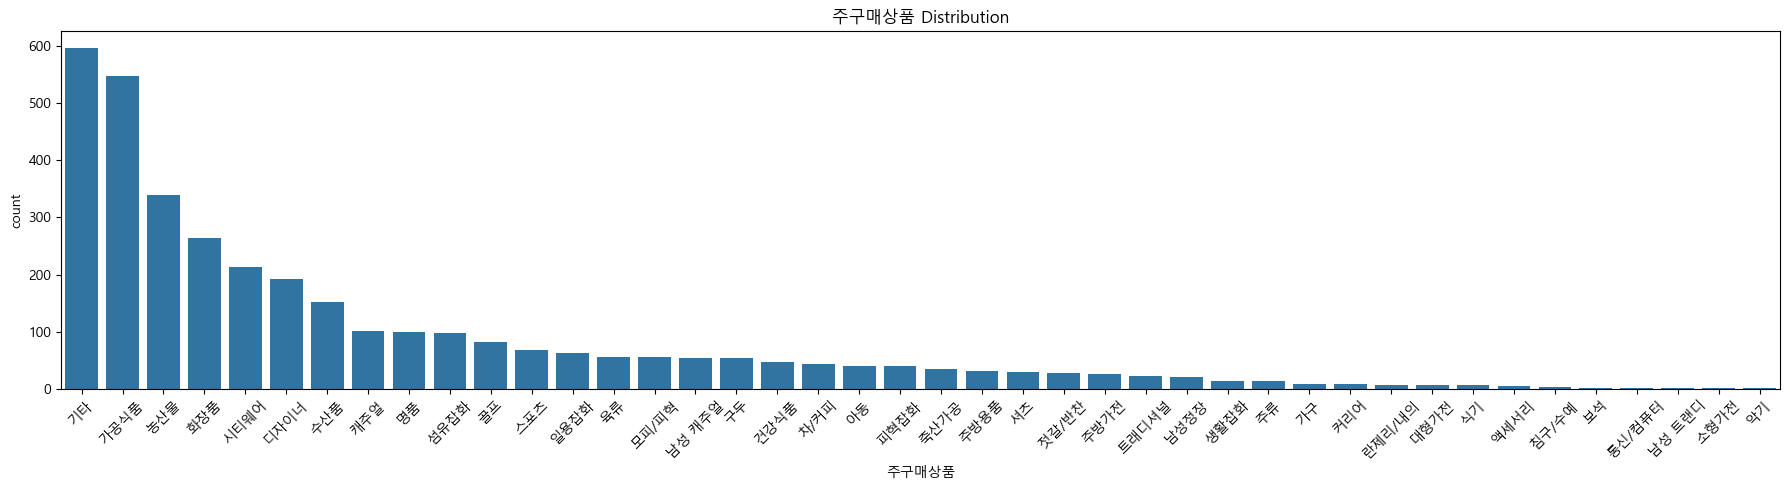

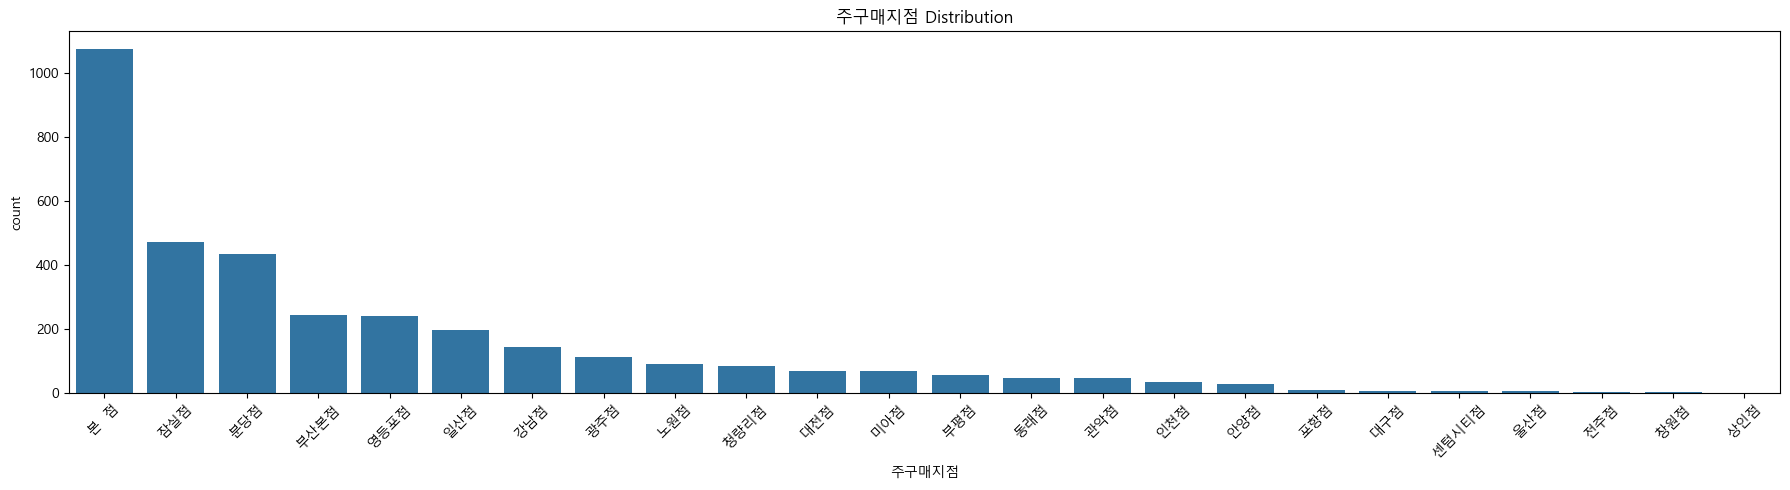

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

categorical_cols = ['주구매상품', '주구매지점']

for col in categorical_cols:
    plt.figure(figsize=(18,5))
    sns.countplot(data=X, x=col, order=X[col].value_counts().index)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
# 기초 통계량 확인
X.describe()

,cust_id,총구매액,최대구매액,환불금액,내점일수,내점당구매건수,주말방문비율,구매주기
count,3500.000000,3.500000e+03,3.500000e+03,1.205000e+03,3500.000000,3500.000000,3500.000000,3500.000000
mean,1749.500000,9.191925e+07,1.966424e+07,2.407822e+07,19.253714,2.834963,0.307246,20.958286
std,1010.507298,1.635065e+08,3.199235e+07,4.746453e+07,27.174942,1.912368,0.289752,24.748682
min,0.000000,-5.242152e+07,-2.992000e+06,5.600000e+03,1.000000,1.000000,0.000000,0.000000
25%,874.750000,4.747050e+06,2.875000e+06,2.259000e+06,2.000000,1.666667,0.027291,4.000000
50%,1749.500000,2.822270e+07,9.837000e+06,7.392000e+06,8.000000,2.333333,0.256410,13.000000
75%,2624.250000,1.065079e+08,2.296250e+07,2.412000e+07,25.000000,3.375000,0.448980,28.000000
max,3499.000000,2.323180e+09,7.066290e+08,5.637530e+08,285.000000,22.083333,1.000000,166.000000


In [14]:
# 결측치 확인
X.isnull().sum()

cust_id       0
총구매액          0
최대구매액         0
환불금액       2295
주구매상품         0
주구매지점         0
내점일수          0
내점당구매건수       0
주말방문비율        0
구매주기          0
dtype: int64

In [15]:
# 왜도 확인
X.skew(numeric_only=True)   ## >2 : 강한 왜도 -> 총구매액, 최대구매액, 환불금액 등 매우 강한 왜도 -> 소수의 고객이 매우 큰 금액을 구매 (전형적인 파레토 분포 형태)

cust_id    0.000000
총구매액       4.170487
최대구매액      6.109304
환불금액       4.917401
내점일수       2.818757
내점당구매건수    2.954445
주말방문비율     0.940755
구매주기       2.096728
dtype: float64

In [16]:
# 상관계수 분석
corr_1 = X[['총구매액', '내점일수']].corr().iloc[0,1]
corr_2 = X[['총구매액', '구매주기']].corr().iloc[0,1]
corr_3 = X[['내점일수', '구매주기']].corr().iloc[0,1]


print(f"총구매액 vs 내점일수 상관계수: {corr_1:.4f}")
print(f"총구매액 vs 구매주기 상관계수: {corr_2:.4f}")
print(f"내점일수 vs 구매주기 상관계수: {corr_3:.4f}")

총구매액 vs 내점일수 상관계수: 0.6591
총구매액 vs 구매주기 상관계수: -0.2129
내점일수 vs 구매주기 상관계수: -0.2932


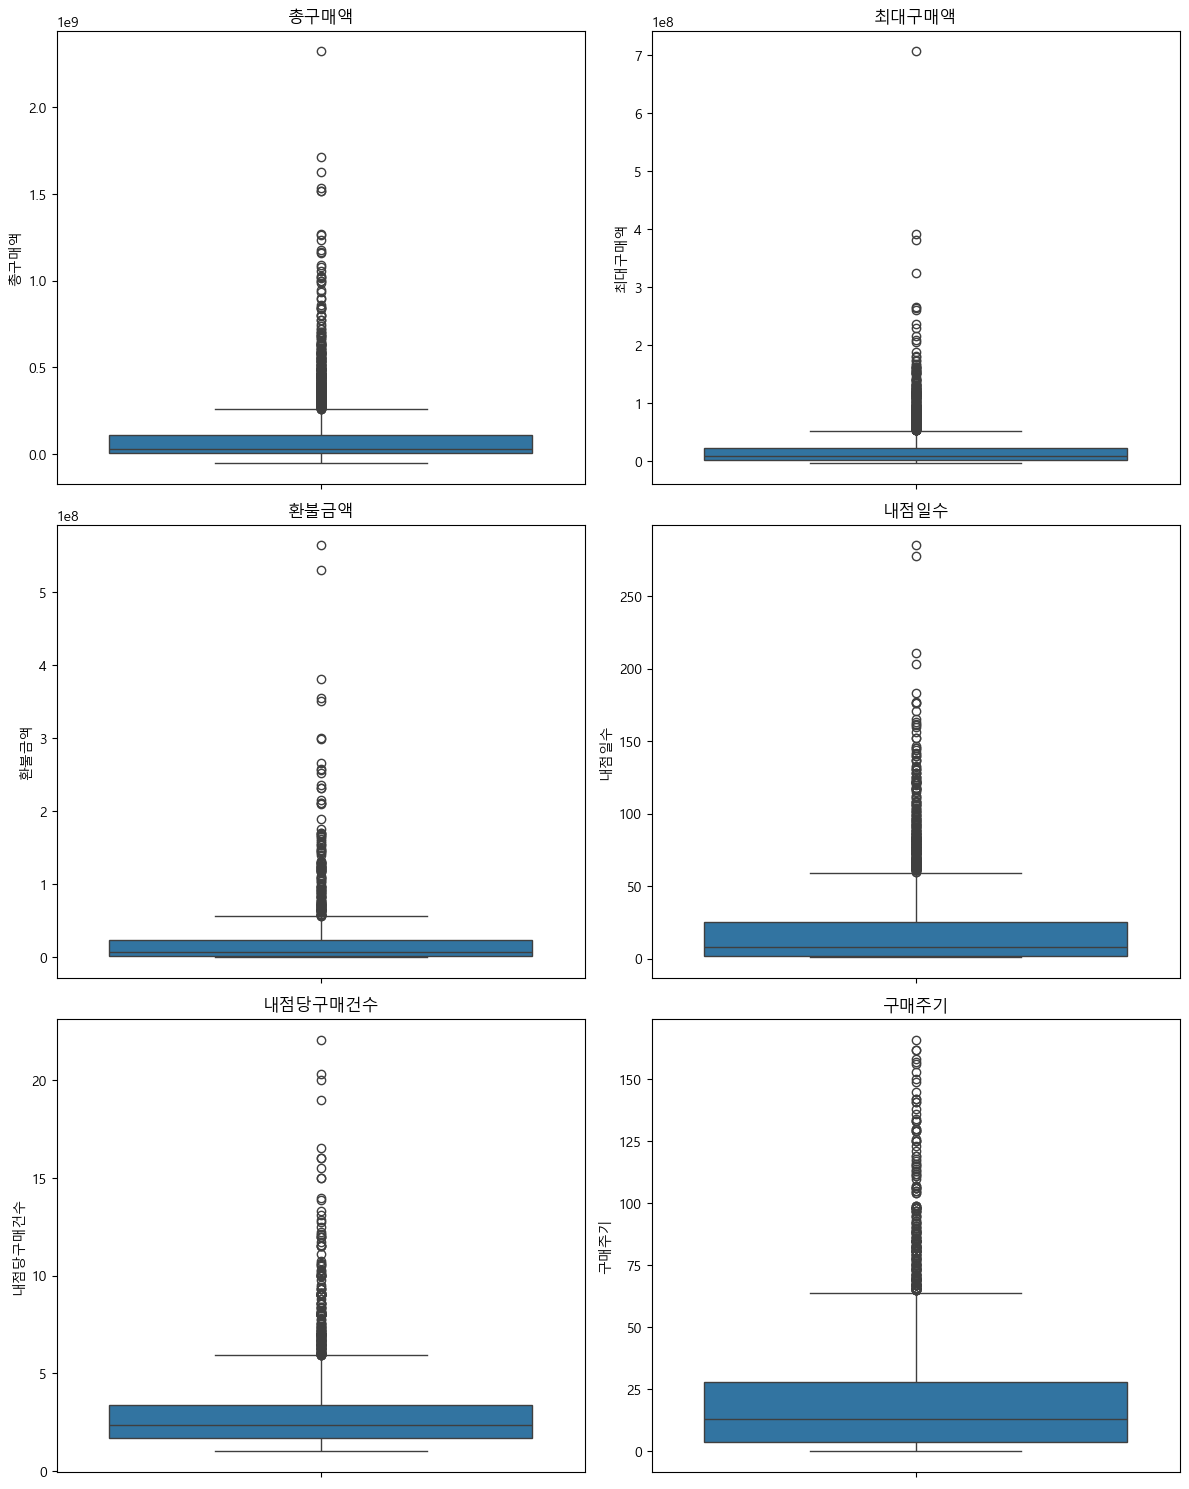

In [17]:
# 이상치 탐색
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    '총구매액',
    '최대구매액',
    '환불금액',
    '내점일수',
    '내점당구매건수',
    '구매주기'
]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, col in enumerate(numeric_cols):
    row = i // 2
    col_idx = i % 2
    
    sns.boxplot(y=X[col], ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

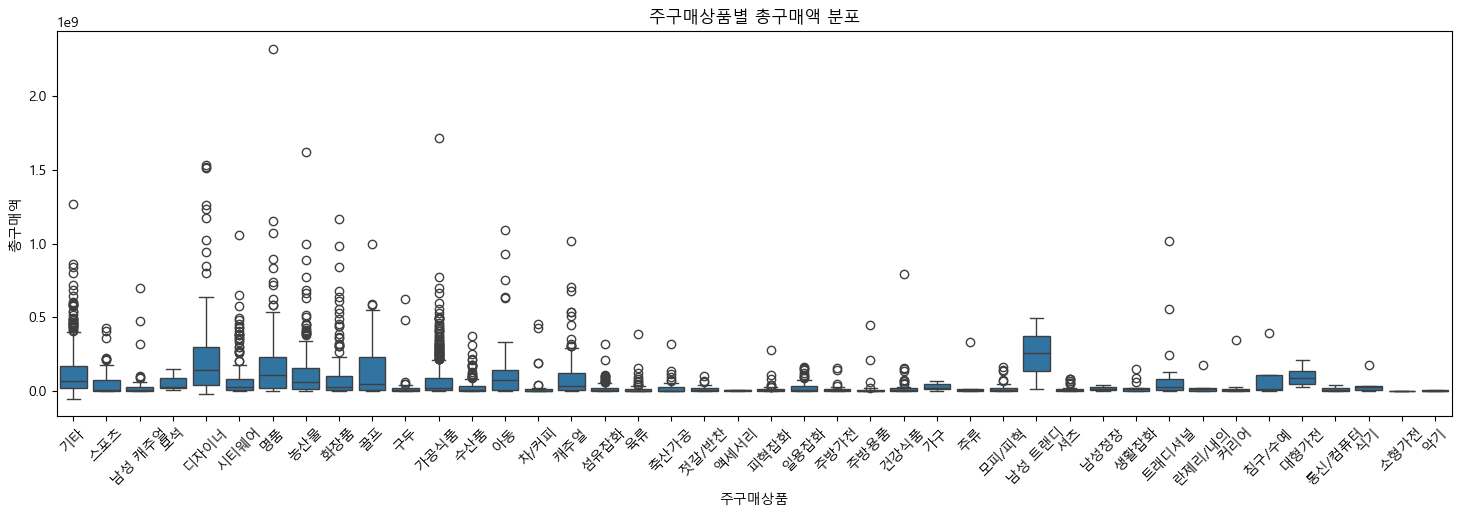

In [18]:
# 이상치 탐색

plt.figure(figsize=(18,5))
sns.boxplot(data=X,
            x='주구매상품',
            y='총구매액')

plt.xticks(rotation=45)
plt.title('주구매상품별 총구매액 분포')
plt.show()

# 3. 데이터 전처리

- 전처리 과정을 통해서 머신러닝에 사용할 수 있는 형태의 데이터 준비
- 필요한 라이브러리를 불러옵니다.

- 인코딩 : LabelEncoder
- 데이터 표준화 : StandardScaler

- 단순히 1부터의 숫자를 부여한 'cust_id'를 수치형 변수로 받아들이면, 결과가 왜곡될 수 있으니 컬럼을 제거합니다.

- 데이터에 결측치가 있는지 확인해보세요
- 결측치에 0으로 채워 넣어 모델 학습에 지장이 없도록 합니다.
- 문자형 범주 데이터를 숫자로 바꾸기 위한 인코딩을 수행합니다.

- 각 데이터에 표준화를 적용하여 데이터의 스케일(크기 차이)을 맞춰줍니다.

- 평균을 0, 표준편차를 1로 맞춰서 → 데이터가 정규 분포 형태로 변환되도록 하세요

In [19]:
# 인코딩 (문자형 -> 숫자형)
from sklearn.preprocessing import LabelEncoder

# 데이터 표준화 (평균 0, 표준편차 1)
from sklearn.preprocessing import StandardScaler

해석
- 단순히 1부터의 숫자를 부여한 'cust_id'를 수치형 변수로 받아들이면, 결과가 왜곡될 수 있으니 컬럼을 제거합니다.

In [20]:
# 1. cust_id 컬럼 제거

X = X.drop(columns=['cust_id'])
y = y.drop(columns=['cust_id'])

In [21]:
X.columns

Index(['총구매액', '최대구매액', '환불금액', '주구매상품', '주구매지점', '내점일수', '내점당구매건수', '주말방문비율',
       '구매주기'],
      dtype='str')

In [22]:
# 2. 결측치 0으로 채우기 (환불금액)

X = X.fillna(0)

해석
- 결측치에 0으로 채워 넣어 모델 학습에 지장이 없도록 합니다.

In [23]:
X.isnull().sum()

총구매액       0
최대구매액      0
환불금액       0
주구매상품      0
주구매지점      0
내점일수       0
내점당구매건수    0
주말방문비율     0
구매주기       0
dtype: int64

# * 라벨인코딩

문자형 범주 데이터를 숫자로 바꾸기 위한 인코딩을 수행.

- 0, 1, 2 (라벨인코딩)
- 원핫인코딩

In [24]:
# 3.  라벨 인코딩 (문자형 -> 숫자형) : 주구매상품, 주구매지점

#객체 생성
le_product = LabelEncoder()
le_store = LabelEncoder()

#인코딩 수행
X['주구매상품'] = le_product.fit_transform(X['주구매상품'])
X['주구매지점'] = le_store.fit_transform(X['주구매지점'])

In [25]:
X[['주구매상품', '주구매지점']].head()

,주구매상품,주구매지점
0,5,0
1,21,19
2,6,1
3,5,2
4,15,8


# * 스케일링

수치형 데이터: 각 데이터에 표준화를 적용하여 데이터의 스케일(크기 차이)을 맞춰줍니다.
- 평균을 0, 표준편차를 1로 맞춰서 -> 데이터가 정규 분포 형태로 변환되도록 할 것

범주형 변수들도 스케일링에 포함되었음.
- 알고리즘에 따라서 포함 여부가 결정될 수 있음. 
- 트리 기반 알고리즘에서는 불필요, 거리 기반 알고리즘에서는 스케일링이 필요할 수 있음
- 순서형, 수치형 변수는 필요할 수 있음
- 명목형일 때는 불필요 >> 원핫인코딩이 적합

In [26]:
# 4. 각 데이터 표준화 적용

scaler = StandardScaler()

# 표준화 적용
scaled_array = scaler.fit_transform(X)

# 다시 DataFrame 형태로 변환
X_scaled = pd.DataFrame(scaled_array, columns=X.columns)

X_scaled #numpy의 array

,총구매액,최대구매액,환불금액,주구매상품,주구매지점,내점일수,내점당구매건수,주말방문비율,구매주기
0,-0.144580,-0.262608,-0.047505,-0.738357,-1.904703,-0.009338,0.554247,0.758623,-0.159962
1,-0.549190,-0.547967,-0.265461,0.490702,1.466677,-0.635003,-0.698168,-1.060530,-0.806554
2,-0.542700,-0.563504,-0.275429,-0.661541,-1.727262,-0.635003,-0.436675,-1.060530,-0.806554
3,-0.463911,-0.460465,-0.275429,-0.738357,-1.549821,-0.046142,-0.204236,0.037746,-0.200374
4,-0.384561,0.135544,-0.275429,0.029805,-0.485175,-0.635003,-0.698168,-1.060530,2.588052
...,...,...,...,...,...,...,...,...,...
3495,-0.542833,-0.519615,-0.275429,-0.891990,-0.485175,-0.671807,-0.436675,2.391196,-0.846966
3496,-0.381022,-0.389656,-0.074430,0.567518,-0.307733,-0.414180,-0.632794,0.532574,0.769513
3497,-0.561796,-0.612398,-0.275429,1.335680,1.821559,-0.671807,-0.959661,-1.060530,-0.846966
3498,-0.550786,-0.583480,-0.275429,2.027026,-0.485175,-0.635003,-0.959661,-1.060530,0.729101


# 4. 학습/테스트 데이터 분할 

- Stratified K-Fold : 이진분류+클래스 비율 유지 및 모델 비교에 적합 >> 추후 고려

In [27]:
from sklearn.model_selection import train_test_split

# 학습/테스트 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 클래스 비율 유지
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2800, 9) Test: (700, 9)


# 5. 모델링 - LogisticRegression

- 본격적으로 모델을 선언하고 학습시킵니다.
- 필요한 라이브러리를 불러옵니다.

- 모델을 선언하여 객체화시킵니다.

- 모델을 학습 데이터에 맞춰 학습시킵니다.

## GPT 추천 모델: 로지스틱 회귀, 랜덤포레스트, XGBoost

모델	추천 이유/장점/단점/이 데이터와의 적합도

로지스틱 회귀	기준: (Baseline) 모델로 적합, 해석 가능	빠름, 과적합 낮음, 변수 영향 해석 가능,	비선형 관계 학습 어려움	⭐⭐⭐   (설명력 중심 분석)
랜덤포레스트:	왜도·이상치에 강함, 비선형 자동 학습,	안정적 성능, 변수 중요도 제공, 튜닝 부담 낮음,	해석력 낮음, 메모리 사용 높음	⭐⭐⭐⭐   (안정성과 성능 균형)
XGBoost:	복합 패턴 학습에 강함, 높은 예측 성능	성능 우수, 과적합 제어 가능	튜닝 필요, 구현 복잡	⭐⭐⭐⭐⭐  (최고 성능 목표)

In [28]:
# 1. 로지스틱 회귀 분석
from sklearn.linear_model import LogisticRegression


In [29]:
#X_train, X_test, y_train, y_test

In [30]:
# 모델을 선언하여 객체화시킴

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

In [31]:
# 모델을 학습 데이터에 맞춰 학습시키기

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

# 5-1. 예측 성능 확인해보기 - LogisticRegresiion

- 학습된 모델로 테스트 데이터에 대한 예측을 수행

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [33]:
# 예측
lr_pred = lr_model.predict(X_test)

- 학습시킨 모델의 성능을 알아봅니다
- 각 평가지표로 모델의 성능을 수치화하여 확인합니다.
- 필요한 라이브러리를 import 하고 성능을 확인해보세요 (정확도, 정밀도, 재현율, f1, confusion_matrix)

# 평가함수 evaluate_calssifier()

In [34]:
def evaluate_classifier(y_true, y_pred):
    # 정확도: 전체 정답 비율
    acc = accuracy_score(y_true, y_pred)

    # 정밀도/재현율/F1: 기본적으로 positive label = 1 기준
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # 혼동행렬: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_true, y_pred)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1       :", round(f1, 4))
    print("\nConfusion Matrix")
    print(cm)

In [35]:
evaluate_classifier(y_test, lr_pred)

Accuracy : 0.6229
Precision: 0.4968
Recall   : 0.2928
F1       : 0.3684

Confusion Matrix
[[359  78]
 [186  77]]


Accuracy는 0.6229로, 전체 데이터 중 약 62.3%를 정확하게 분류하였다.

Confusion Matrix를 보면 실제 0 클래스는 비교적 잘 예측했지만, 
실제 1 클래스는 상당 부분을 0으로 잘못 분류하였다. 
특히 FN(False Negative)이 186으로 나타나 실제 1을 많이 놓친 것을 확인할 수 있다.

Precision은 0.4968로, 모델이 1이라고 예측한 데이터 중 약 49.7%만 실제 1로 나타났다.

Recall은 0.2928로, 실제 1 데이터 중 약 29.3%만 정확하게 탐지하였다. 
이는 모델이 클래스 1을 제대로 식별하지 못하는 경향이 있음을 의미한다.

F1 score는 0.3684로 Precision과 Recall의 균형 성능이 높지 않은 것으로 나타났다.

종합적으로 보면, 해당 로지스틱 회귀 모델은 전체 정확도는 보통 수준이지만 
클래스 1에 대한 탐지 성능(Recall)이 낮아 분류 성능이 충분하지 않은 것으로 판단된다.

================================================== LogisticRegression 성능(class_weight 지정안한 경우)
정확도 (Accuracy): 0.6329 정밀도 (Precision): 0.5455 재현율 (Recall): 0.1369 F1 Score: 0.2188

Confusion Matrix: [[407 30] [227 36]]

# 6. 모델링 - DecisionTreeClassifier

In [37]:
# 2. 의사결정나무 분석
from sklearn.tree import DecisionTreeClassifier

In [39]:
# 모델을 선언하여 객체화
dt_model = DecisionTreeClassifier(
    max_depth=5,        # 트리 깊이 제한 (과적합 방지)
    random_state=42
)

In [40]:
# 모델을 학습 데이터에 맞게 학습시키기
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# 6-1. 예측 성능 확인해보기 - DecisionTreeClassifier

In [41]:
# 테스트 데이터 예측
y_pred_dt = dt_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.63
Precision: 0.515625
Recall   : 0.2509505703422053
F1 score : 0.3375959079283887

Confusion Matrix
[[375  62]
 [197  66]]


# 7. 모델링 - RandomForestClassifier

Accuracy는 0.63으로, 전체 데이터 중 약 63%를 정확하게 분류하였다.

Confusion Matrix를 보면 실제 0 클래스는 비교적 잘 예측했지만,
실제 1 클래스는 상당 부분을 0으로 잘못 분류하였다.
특히 FN(False Negative)이 197로 나타나 실제 1을 많이 놓친 것을 확인할 수 있다.

Precision은 0.5156으로, 모델이 1이라고 예측한 데이터 중 약 51.6%가 실제 1로 나타났다.

Recall은 0.2510으로, 실제 1 데이터 중 약 25.1%만 정확하게 탐지하였다.
이는 모델이 클래스 1을 충분히 탐지하지 못하는 경향이 있음을 의미한다.

F1 score는 0.3376으로 Precision과 Recall의 균형 성능이 높지 않은 것으로 나타났다.

종합적으로 보면, 해당 모델은 전체 정확도는 약 63% 수준이지만
클래스 1에 대한 탐지 성능(Recall)이 낮아 실제 1 데이터를 많이 놓치는 경향이 있는 것으로 판단된다.

In [57]:
# 3. 랜덤포레스트 분석
from sklearn.ensemble import RandomForestClassifier

In [58]:
# 모델을 선언하여 객체화
rf_model = RandomForestClassifier(
    n_estimators=100,   # 생성할 트리 개수
    max_depth=5,  # 트리 깊이 제한 (과적합 방지)
    class_weight='balanced',  
    random_state=42
)

In [59]:
# 모델을 학습 데이터에 맞게 학습시키기
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

# 7-1. 예측 성능 확인해보기 - RandomForestClassifier

In [60]:
# 테스트 데이터 예측
y_pred_rf = rf_model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.5842857142857143
Precision: 0.4590643274853801
Recall   : 0.596958174904943
F1 score : 0.5190082644628099

Confusion Matrix
[[252 185]
 [106 157]]


Accuracy는 0.6557로, 전체 데이터 중 약 65.6%를 정확하게 분류하였다.

Confusion Matrix를 보면 실제 0 클래스는 비교적 높은 비율로 정확하게 예측하였다.
실제 0 중 385건을 올바르게 분류하고, 52건을 1로 잘못 예측하였다.

반면 실제 1 클래스는 일부만 정확하게 탐지하였다.
실제 1 중 74건을 올바르게 예측하였지만, 189건을 0으로 잘못 분류하여
여전히 FN(False Negative)이 많은 것을 확인할 수 있다.

Precision은 0.5873으로, 모델이 1이라고 예측한 데이터 중 약 58.7%가 실제 1로 나타났다.

Recall은 0.2814로, 실제 1 데이터 중 약 28.1%만 정확하게 탐지하였다.
이는 모델이 클래스 1을 충분히 식별하지 못하는 경향이 있음을 의미한다.

F1 score는 0.3805로 Precision과 Recall을 종합적으로 고려했을 때
전반적인 분류 성능은 크게 높지 않은 것으로 나타났다.

종합적으로 보면 Random Forest 모델은 이전 모델보다 Precision과 Accuracy는
다소 개선되었지만, Recall이 여전히 낮아 실제 1 데이터를 많이 놓치는
문제가 존재하는 것으로 판단된다.

class_weight = 'balanced' 적용 시,
Accuracy는 0.5843으로, 전체 데이터 중 약 58.4%를 정확하게 분류하였다.
이는 이전 모델보다 Accuracy는 다소 감소한 결과이다.

Confusion Matrix를 보면 실제 0 클래스 중 252건을 올바르게 분류하고
185건을 1로 잘못 예측하였다. 이전 모델에 비해 FP(False Positive)가
증가하여 0을 1로 잘못 예측하는 경우가 많아진 것을 확인할 수 있다.

반면 실제 1 클래스의 경우 157건을 올바르게 예측하고
106건을 0으로 잘못 분류하였다. 이전 모델에 비해 FN(False Negative)이
감소하여 실제 1 데이터를 더 많이 탐지한 것으로 나타났다.

Precision은 0.4591로, 모델이 1이라고 예측한 데이터 중 약 45.9%가
실제 1로 나타났다. 이는 이전 모델보다 Precision이 다소 감소한 결과이다.

Recall은 0.5970으로, 실제 1 데이터 중 약 59.7%를 정확하게 탐지하였다.
이는 이전 모델보다 크게 향상된 수치로, 모델이 클래스 1을
더 잘 탐지하도록 개선된 것을 의미한다.

F1 score는 0.5190으로 Precision과 Recall의 균형 성능이
이전 모델보다 개선된 것으로 나타났다.

종합적으로 보면 class_weight='balanced'를 적용하면서
Accuracy와 Precision은 일부 감소하였지만,
Recall이 크게 증가하여 클래스 1을 탐지하는 성능이 개선된 것으로 판단된다.

# 8. 모델링 - XGBOOST

In [62]:
# 4. XGBoost 분석
from xgboost import XGBClassifier

In [63]:
# 모델을 선언하여 객체화
xgb_model = XGBClassifier(
    n_estimators=200,     # 트리 개수
    max_depth=5,          # 트리 깊이
    learning_rate=0.05,   # 학습률
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [64]:
# 모델 학습
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# 8-1. 예측 성능 확인해보기 - XGBOOST

In [65]:
# 테스트 데이터 예측
y_pred_xgb = xgb_model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 score :", f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.6357142857142857
Precision: 0.5217391304347826
Recall   : 0.3650190114068441
F1 score : 0.42953020134228187

Confusion Matrix
[[349  88]
 [167  96]]


threshold 설정을 변경하며 모델 성능을 보는 방법

In [68]:
# xgb_w 또는 현재 사용 중인 xgb_model 이름에 맞춰 주세요.
# 아래는 xgb_model 기준으로 작성합니다.
proba = xgb_model.predict_proba(X_test)[:, 1]
proba

array([0.5463719 , 0.5059332 , 0.46405786, 0.8975905 , 0.1805683 ,
       0.25919065, 0.19658378, 0.2937427 , 0.24973159, 0.37211993,
       0.0985228 , 0.6540516 , 0.401338  , 0.17495978, 0.5723553 ,
       0.5909013 , 0.4366275 , 0.293497  , 0.26954103, 0.25159124,
       0.50948215, 0.31529695, 0.394984  , 0.37077355, 0.5025839 ,
       0.10671223, 0.41480246, 0.08043993, 0.5346174 , 0.3073824 ,
       0.5465023 , 0.09999272, 0.8728278 , 0.10215329, 0.3147273 ,
       0.8161736 , 0.14372964, 0.6609622 , 0.29632264, 0.7462241 ,
       0.24809876, 0.24641468, 0.07651533, 0.5763687 , 0.19135378,
       0.42692515, 0.32545733, 0.33108026, 0.32753268, 0.3381152 ,
       0.49326515, 0.33076873, 0.7936936 , 0.4125769 , 0.75885713,
       0.31094196, 0.7273189 , 0.12664625, 0.32206038, 0.16393498,
       0.32721266, 0.12454071, 0.65970105, 0.32243392, 0.14733292,
       0.30797648, 0.02519741, 0.62818456, 0.22143376, 0.5385857 ,
       0.48145443, 0.24499448, 0.3333651 , 0.44517362, 0.44475

In [69]:
rows = []
for thr in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]: #임계값에 따라 0/1 인지 판정만 다시한다.
    pred_thr = (proba >= thr).astype(int)

    rows.append({
        "threshold": thr,
        "accuracy": round(accuracy_score(y_test, pred_thr), 4),
        "precision": round(precision_score(y_test, pred_thr), 4),
        "recall": round(recall_score(y_test, pred_thr), 4),
        "f1": round(f1_score(y_test, pred_thr), 4)
    })

thr_result = pd.DataFrame(rows)
display(thr_result)

best_thr = float(thr_result.sort_values("f1", ascending=False).iloc[0]["threshold"])
best_pred = (proba >= best_thr).astype(int)

print("F1 기준 best threshold:", best_thr)
print("Confusion Matrix\n", confusion_matrix(y_test, best_pred))

,threshold,accuracy,precision,recall,f1
0,0.35,0.5786,0.4545,0.6084,0.5203
1,0.40,0.6071,0.4796,0.5361,0.5063
2,0.45,0.6286,0.5063,0.4601,0.4821
3,0.50,0.6357,0.5217,0.3650,0.4295
4,0.55,0.6343,0.5267,0.2624,0.3503
5,0.60,0.6329,0.5349,0.1749,0.2636


F1 기준 best threshold: 0.35
Confusion Matrix
 [[245 192]
 [103 160]]


Accuracy는 0.6357로, 전체 데이터 중 약 63.6%를 정확하게 분류하였다.

Confusion Matrix를 보면 실제 0 클래스 중 349건을 올바르게 분류하고
88건을 1로 잘못 예측하였다. 이는 모델이 클래스 0을 비교적 안정적으로
분류하고 있음을 보여준다.

실제 1 클래스의 경우 96건을 올바르게 예측하였으며,
167건을 0으로 잘못 분류하였다. FN(False Negative)이 여전히 존재하지만
이전 모델들과 비교했을 때 실제 1을 탐지하는 비율이 다소 개선된 것을 확인할 수 있다.

Precision은 0.5217로, 모델이 1이라고 예측한 데이터 중 약 52.2%가 실제 1로 나타났다.

Recall은 0.3650으로, 실제 1 데이터 중 약 36.5%를 정확하게 탐지하였다.
이는 이전 모델들보다 클래스 1을 식별하는 성능이 다소 개선된 결과이다.

F1 score는 0.4295로 Precision과 Recall을 종합적으로 고려했을 때
전체적인 분류 성능이 이전 모델 대비 일부 개선된 것으로 나타났다.

종합적으로 보면 XGBoost 모델은 Accuracy와 Precision을 유지하면서
Recall과 F1 score가 개선되어 클래스 1을 탐지하는 성능이
다소 향상된 것으로 판단된다.

# 7. 위 4가지 모델의 학습 & 예측 & 평가 결과를 확인하고 최고 성능을 내는 모델을 찾아봅시다!

- 어떤 모델이 가장 성능이 좋은가요 ?

<결과 정리>
| Model                        | Accuracy   | Precision  | Recall     | F1         |
| ---------------------------- | ---------- | ---------- | ---------- | ---------- |
| Logistic Regression          | 0.6229     | 0.4968     | 0.2928     | 0.3684     |
| Decision Tree                | 0.6300     | 0.5156     | 0.2510     | 0.3376     |
| Random Forest                | **0.6557** | **0.5873** | 0.2814     | 0.3805     |
| Random Forest (class_weight) | 0.5843     | 0.4591     | **0.5970** | **0.5190** |
| XGBoost                      | 0.6357     | 0.5217     | 0.3650     | 0.4295     |


가장 성능이 좋은 모델
Random Forest (class_weight='balanced')

여러 분류 모델(Logistic Regression, Decision Tree, Random Forest, XGBoost)을
적용하여 고객 성별 분류 성능을 비교하였다.

모델 평가 결과 Random Forest 모델에 class_weight='balanced' 옵션을
적용한 모델이 가장 높은 성능을 보였다.

해당 모델의 Accuracy는 0.584로 다른 모델보다 다소 낮았지만,
Recall이 0.597로 가장 높게 나타나 실제 클래스 1 데이터를 가장 많이
탐지한 것으로 확인되었다.

또한 Precision과 Recall의 균형을 나타내는 F1 score가 0.519로
다른 모델(Logistic Regression, Decision Tree, Random Forest, XGBoost)
보다 가장 높은 값을 보였다.

Confusion Matrix에서도 실제 1을 올바르게 예측한 TP가 증가하고
실제 1을 놓친 FN이 감소한 것을 확인할 수 있었다.

따라서 Accuracy만 기준으로 평가하기보다 Precision과 Recall을
종합적으로 고려하는 F1 score 기준에서 Random Forest
(class_weight='balanced') 모델이 가장 우수한 성능을 보인 것으로
판단된다.

### 모델 성능 최적화를 위한 Next Step
- 모델별로 또는 모델을 정하고 난 후, 성능을 Maximaized하기 위해 GridSearchCV를 활용하여 최적의 파라미터 찾기
- PCA (주성분 분석) 등을 활용하여 변수 재선정